# Predict a range. Measure how often it works.

A model proposes a response interval for each input. We want to know how
often these intervals cover new outcomes **across the population of inputs**.
This is called **marginal coverage**.

We can measure it using an ordinary held-out dataset: each new input comes
with one response. No repeated measurements at an exact input are needed.

## 1. Start with data; allow the model to be wrong

Our example population has random inputs and a curved response:

$$X\sim\mathrm{Uniform}[-1,1],\qquad
Y=1+2X+2X^2+\varepsilon,\quad \varepsilon\sim\mathcal N(0,0.5^2).$$

We will fit a straight line. It cannot represent this true mean.
All data below are simulated; in an application, use observations from
the actual population you want to predict.


In [1]:
import math
from statistics import NormalDist
import numpy as np
import matplotlib.pyplot as plt

TEST_COUNT = 10_000       # choose the sample size before validation
FAILURE_CHANCE = 0.05

train_rng, validation_rng = [
    np.random.default_rng(s)
    for s in np.random.SeedSequence(20260919).spawn(2)
]

def actual_mean(x):
    return 1 + 2*x + 2*x*x

x_train = train_rng.uniform(-1, 1, 20)
y_train = actual_mean(x_train) + train_rng.normal(0, 0.5, 20)


## 2. Use Bayesian regression to propose intervals

Our working model is $Y=w_0+w_1x+\text{noise}$, with Gaussian prior
$\mathbf w\sim\mathcal N(0,4I)$ and Gaussian noise variance $0.25$.

Bishop's regression calculation gives posterior mean $m$ and covariance $S$.
At input $x$, write $\phi=[1,x]^T$. The model's predictive distribution is

$$Y\mid x,D\ \sim\ \mathcal N\!\left(\phi^Tm,\ 0.25+\phi^TS\phi\right).$$

The $0.25$ accounts for noise in a **new response**.
Use the middle 99% of this Gaussian as the proposed interval $I_D(x)$.
That nominal 99% is a model setting; its actual coverage still needs testing.
[Calculation reference](https://www.microsoft.com/en-us/research/wp-content/uploads/2016/05/prml-slides-3.pdf).


In [2]:
alpha, beta = 0.25, 4.0
Phi = np.column_stack([np.ones(len(x_train)), x_train])
precision = alpha*np.eye(2) + beta*Phi.T@Phi
S = np.linalg.solve(precision, np.eye(2))
m = np.linalg.solve(precision, beta*Phi.T@y_train)
z = NormalDist().inv_cdf(0.995)

def proposed_intervals(x):
    phi = np.column_stack([np.ones(len(x)), x])
    center = phi@m
    variance = 1/beta + np.einsum("ij,jk,ik->i", phi, S, phi)
    radius = z*np.sqrt(variance)
    return center-radius, center+radius

print("Fitted coefficients:", np.round(m, 3))


Fitted coefficients: [1.721 2.27 ]


**Freeze this fitted rule now.** It produces different endpoints at different
inputs, but its coefficients and nominal level stay fixed throughout validation.

## 3. Check each fresh response against its own interval

Draw 10,000 independent input–response pairs from the same population.
These responses come from the actual process, not the fitted model.


In [3]:
validation_x = validation_rng.uniform(-1, 1, TEST_COUNT)
validation_y = actual_mean(validation_x) + validation_rng.normal(0, 0.5, TEST_COUNT)

low, high = proposed_intervals(validation_x)
inside = (validation_y >= low) & (validation_y <= high)
hits = int(inside.sum())
observed_coverage = hits / TEST_COUNT
print(f"{hits:,} of {TEST_COUNT:,} responses inside their own intervals")
print(f"Measured marginal coverage: {100*observed_coverage:.2f}%")


9,170 of 10,000 responses inside their own intervals
Measured marginal coverage: 91.70%


**9,170 of 10,000** are inside: **91.70% measured coverage**.
The model's nominal 99% did not describe this population.

## 4. Turn the measurement into a coverage guarantee

Hold the fitted model $D$ fixed. Our target is

$$p_D=\Pr_{(X,Y)\text{ from the population}}\{Y\in I_D(X)\}.$$

Each held-out pair contributes an independent 0-or-1 observation with mean
$p_D$. The one-sided Hoeffding bound gives a 95% lower confidence bound:

$$L=\max\!\left(0,\ \widehat p-
\sqrt{\frac{\log(1/0.05)}{2N}}\right).$$


In [4]:
allowance = math.sqrt(math.log(1/FAILURE_CHANCE) / (2*TEST_COUNT))
lower_bound = max(0, observed_coverage-allowance)
reported_percent = math.floor(1000*lower_bound) / 10
print(f"Hoeffding allowance: {100*allowance:.3f} percentage points")
print(f"Lower coverage bound: {100*lower_bound:.3f}%")
print(f"With 95% confidence, marginal coverage is at least {reported_percent:.1f}%.")


Hoeffding allowance: 1.224 percentage points
Lower coverage bound: 90.476%
With 95% confidence, marginal coverage is at least 90.4%.


Subtract **1.224 percentage points** from 91.70%, giving **90.476%**.
Round downward when reporting the guarantee:

> With 95% confidence, this frozen interval rule covers at least **90.4%**
> of future input–response pairs drawn from the same population.

The **95%** concerns the validation procedure: its chance of overstating
$p_D$ is at most 5%. The **90.4%** concerns coverage of future pairs.
Neither the straight-line model nor the Gaussian prior needs to be correct
for this statement.
[Hoeffding reference](https://www.cs.rpi.edu/academics/courses/spring06/random/hoefding.pdf).

## 5. Show what validation measured


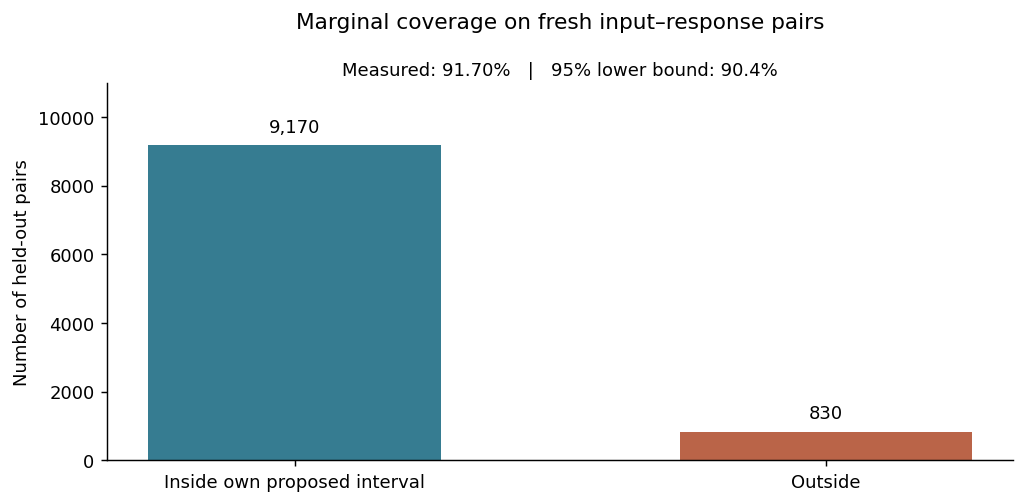

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = [hits, TEST_COUNT-hits]
bars = ax.bar(["Inside own proposed interval", "Outside"],
              counts, color=["#367c91", "#ba6448"], width=0.55)
ax.bar_label(bars, labels=[f"{n:,}" for n in counts], padding=5)
ax.set_ylim(0, TEST_COUNT*1.10)
ax.set_ylabel("Number of held-out pairs")
ax.set_title("Marginal coverage on fresh input–response pairs", pad=30)
ax.text(0.5, 1.02,
        f"Measured: {100*observed_coverage:.2f}%   |   "
        f"95% lower bound: {reported_percent:.1f}%",
        transform=ax.transAxes, ha="center")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()


**Scope:** the guarantee averages over inputs. Some inputs may have worse
coverage; it does not certify coverage at a particular input.

Validation pairs must be independent of training and of each other, and
represent the future population. Choose the sample size in advance.
If you change the rule after seeing validation results, check the revised
rule on fresh data. More measurements shrink the Hoeffding allowance;
they do not improve the rule's actual coverage.
